

## 多维度分析目标

1. **时间维度**: 出版年份分布与趋势分析
2. **价格维度**: 原价、折后价、折扣率的多维分析  
3. **评论维度**: 销量/热度分布特征
4. **出版社维度**: 出版社竞争力分析
5. **分类维度**: 图书领域分布分析
6. **综合维度**: 价格-销量-年份交叉分析

In [47]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 步骤1: 尝试清除字体缓存（忽略权限错误）
try:
    cache_dir = os.path.expanduser('~/.cache/matplotlib')
    if os.path.exists(cache_dir):
        import shutil
        shutil.rmtree(cache_dir)
        print("✓ 已清除字体缓存")
except Exception as e:
    print(f"注: 清除缓存跳过 ({e})")

# 步骤2: 强制重新加载字体
try:
    fm._load_fontmanager(try_read_cache=False)
    print("✓ 已重新加载字体")
except:
    pass

# 导入其他库
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 步骤3: 设置seaborn样式
sns.set_style('whitegrid')

# 步骤4: 重新设置中文字体（必须在sns.set_style之后）
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'SimHei', 'Microsoft YaHei',   # Windows
    'Arial Unicode MS', 'Heiti SC',      # Mac  
    'Noto Sans CJK SC',             # Linux
    'DejaVu Sans'                   # 后备
]
plt.rcParams['axes.unicode_minus'] = False

print("✓ 字体设置完成")
print("当前字体设置:", plt.rcParams['font.sans-serif'])


✓ 已重新加载字体
✓ 字体设置完成
当前字体设置: ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'Heiti SC', 'Noto Sans CJK SC', 'DejaVu Sans']


In [ ]:
# ============================================================
# 数据加载与输出目录配置
# ============================================================

# 1. 加载清洗后的数据
df = pd.read_csv('../data_clean/python_books_clean.csv')

# 2. 配置输出目录（统一保存到项目根目录的 output/ 文件夹）
#    - notebook_path: 当前 notebook 的绝对路径
#    - project_root: code/ 的父目录（即 Proj_homework/）
#    - output_dir: 项目根目录下的 output 文件夹
notebook_path = os.path.abspath('03_data_analysis.ipynb')
project_root = os.path.dirname(os.path.dirname(notebook_path))
output_dir = os.path.join(project_root, 'output')
os.makedirs(output_dir, exist_ok=True)
print(f'✓ output 目录已就绪: {output_dir}')

In [ ]:
# ↑ 已合并到上一 cell

In [50]:
print('=' * 60)
print('数据基本信息')
print('=' * 60)

print('\n数值型字段统计:')
print(df[['年份', '评论数', '原价', '折后价', '折扣率']].describe())

print('\n缺失值情况:')
print(df.isnull().sum())

数据基本信息

数值型字段统计:
                年份           评论数          原价         折后价         折扣率
count   133.000000    137.000000  137.000000  137.000000  137.000000
mean   2017.676692    330.197080   85.053723   20.832993    0.279840
std       3.640157   2382.484723   46.864221   28.820803    0.272813
min    2006.000000      0.000000   14.880000    1.750000    0.020300
25%    2016.000000      0.000000   59.800000    7.240000    0.080100
50%    2018.000000      0.000000   90.200000    9.900000    0.107600
75%    2020.000000      1.000000   99.620000   19.360000    0.426900
max    2025.000000  25616.000000  320.360000  238.000000    1.000000

缺失值情况:
排名       0
书名       0
作者      15
出版社      0
年份       4
评论数      0
原价       0
折后价      0
折扣率      0
链接       0
图书分类     0
dtype: int64


---

## 一、时间维度分析

### 1.1 出版年份分布

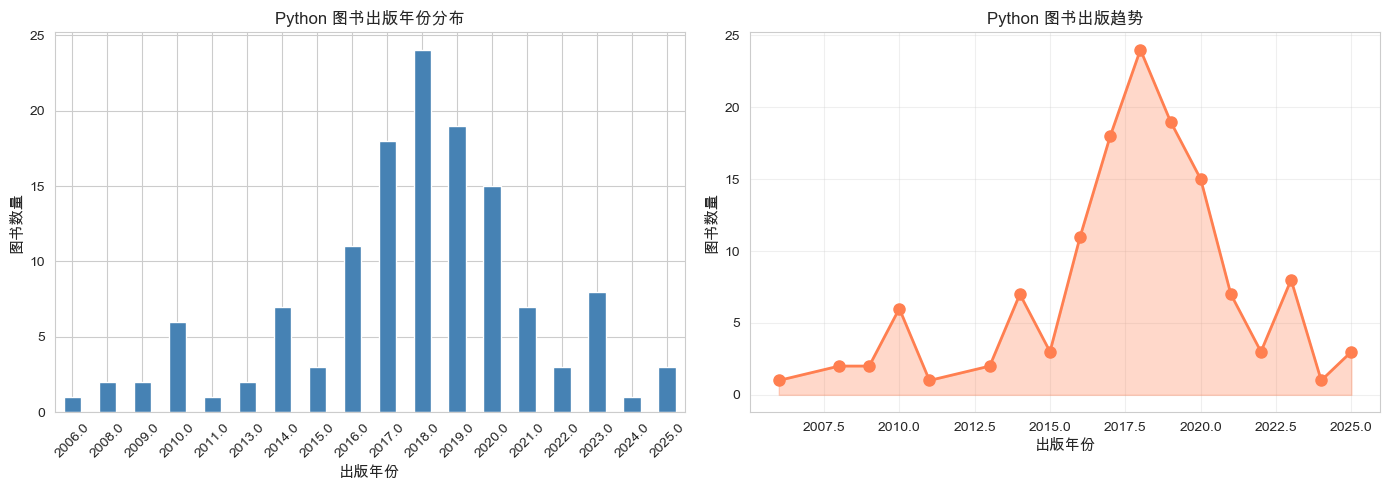


年份分布:
年份
2006.0     1
2008.0     2
2009.0     2
2010.0     6
2011.0     1
2013.0     2
2014.0     7
2015.0     3
2016.0    11
2017.0    18
2018.0    24
2019.0    19
2020.0    15
2021.0     7
2022.0     3
2023.0     8
2024.0     1
2025.0     3
Name: count, dtype: int64

出版年份范围: 2006.0 - 2025.0


In [51]:
# 年份分布
year_counts = df['年份'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 柱状图
year_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_xlabel('出版年份', fontsize=11)
ax1.set_ylabel('图书数量', fontsize=11)
ax1.set_title('Python 图书出版年份分布', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# 趋势图
ax2.plot(year_counts.index, year_counts.values, marker='o', linewidth=2, markersize=8, color='coral')
ax2.fill_between(year_counts.index, year_counts.values, alpha=0.3, color='coral')
ax2.set_xlabel('出版年份', fontsize=11)
ax2.set_ylabel('图书数量', fontsize=11)
ax2.set_title('Python 图书出版趋势', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/01_time_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n年份分布:')
print(year_counts)
print(f'\n出版年份范围: {df["年份"].min()} - {df["年份"].max()}')

### 1.2 年份与热度交叉分析

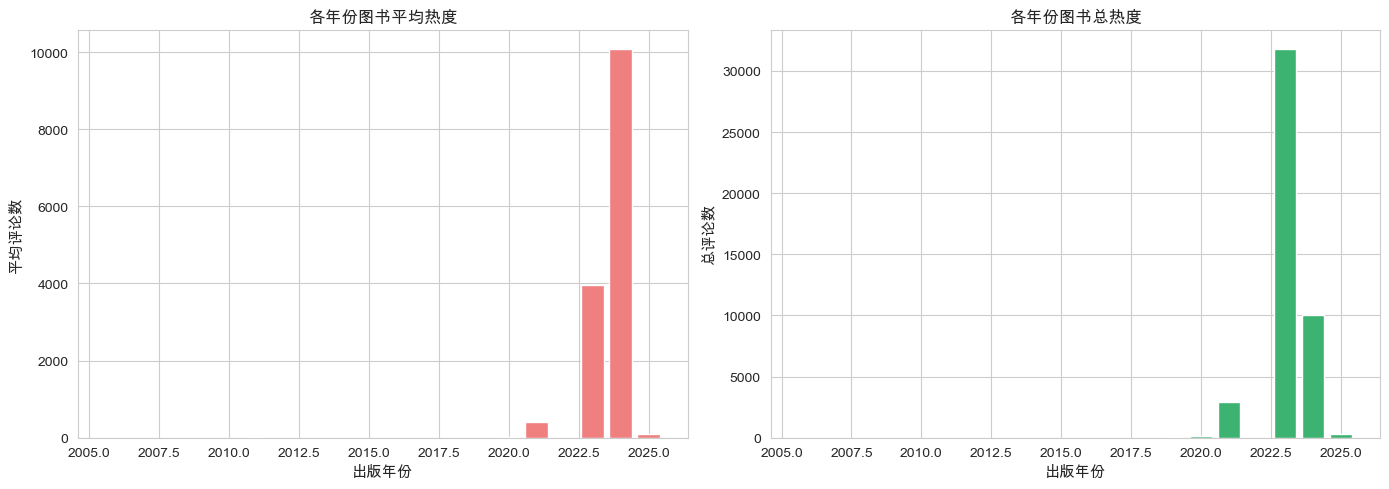

年份-热度统计:
        年份         平均评论数   总评论数  图书数量
0   2006.0      0.000000      0     1
1   2008.0      0.500000      1     2
2   2009.0      0.500000      1     2
3   2010.0      0.166667      1     6
4   2011.0     11.000000     11     1
5   2013.0      2.500000      5     2
6   2014.0      0.285714      2     7
7   2015.0      0.333333      1     3
8   2016.0      1.000000     11    11
9   2017.0      0.611111     11    18
10  2018.0      0.041667      1    24
11  2019.0      2.000000     38    19
12  2020.0      8.933333    134    15
13  2021.0    413.714286   2896     7
14  2022.0      0.000000      0     3
15  2023.0   3971.750000  31774     8
16  2024.0  10074.000000  10074     1
17  2025.0     91.000000    273     3


In [52]:
year_comments = df.groupby('年份')['评论数'].agg(['mean', 'sum', 'count']).reset_index()
year_comments.columns = ['年份', '平均评论数', '总评论数', '图书数量']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(year_comments['年份'], year_comments['平均评论数'], color='lightcoral', edgecolor='white')
ax1.set_xlabel('出版年份', fontsize=11)
ax1.set_ylabel('平均评论数', fontsize=11)
ax1.set_title('各年份图书平均热度', fontsize=12, fontweight='bold')

ax2.bar(year_comments['年份'], year_comments['总评论数'], color='mediumseagreen', edgecolor='white')
ax2.set_xlabel('出版年份', fontsize=11)
ax2.set_ylabel('总评论数', fontsize=11)
ax2.set_title('各年份图书总热度', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/02_year_heat.png', dpi=300, bbox_inches='tight')
plt.show()

print('年份-热度统计:')
print(year_comments)

---

## 二、价格维度分析

### 2.1 价格分布特征

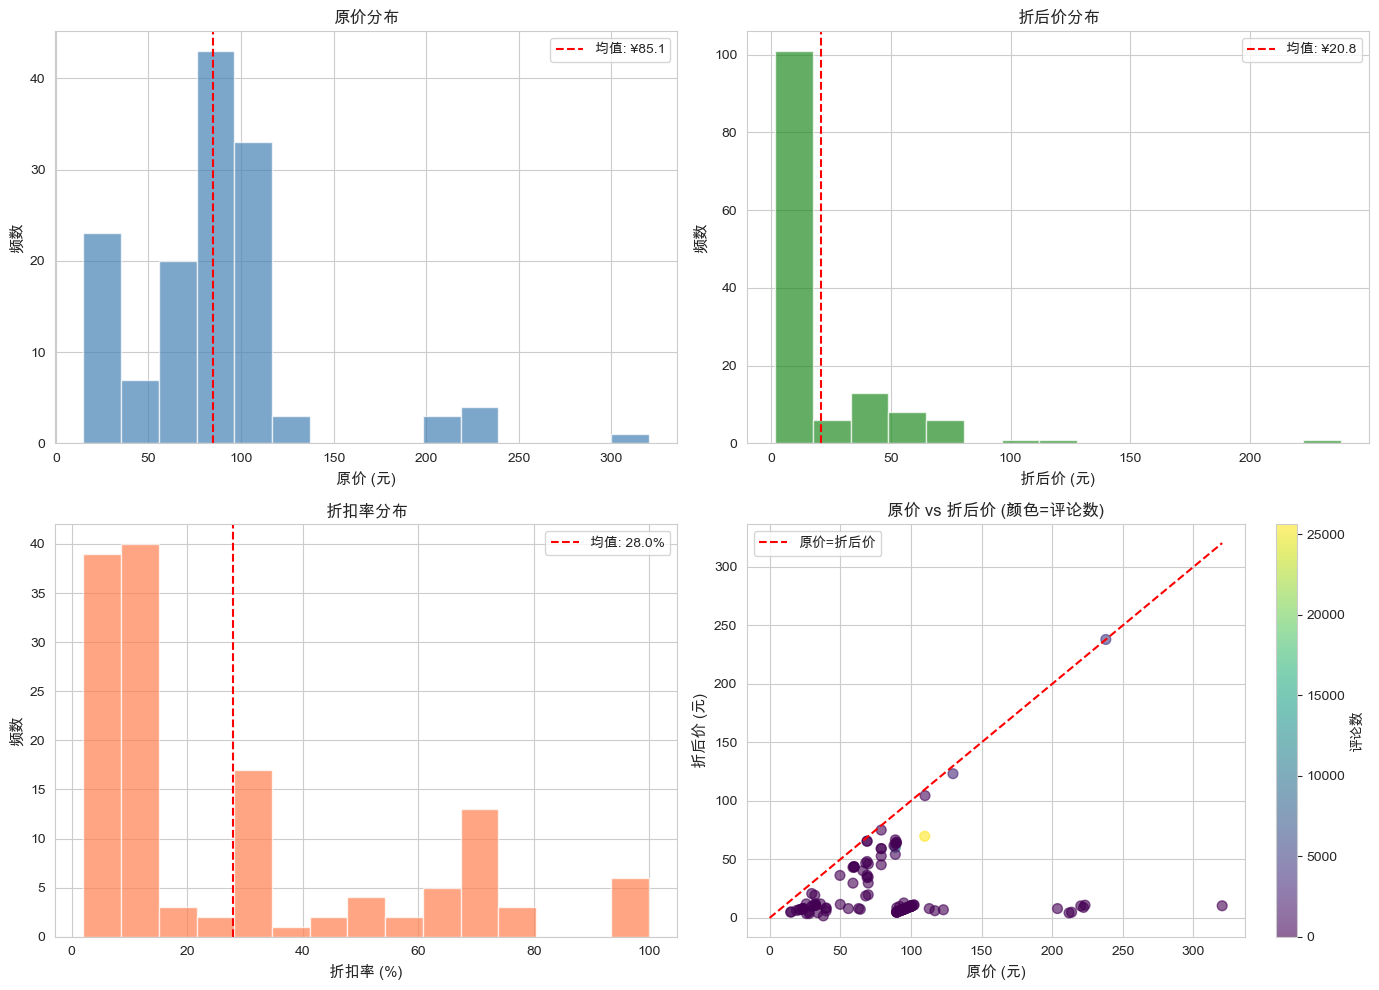

价格统计:
               原价         折后价         折扣率
count  137.000000  137.000000  137.000000
mean    85.053723   20.832993    0.279840
std     46.864221   28.820803    0.272813
min     14.880000    1.750000    0.020300
25%     59.800000    7.240000    0.080100
50%     90.200000    9.900000    0.107600
75%     99.620000   19.360000    0.426900
max    320.360000  238.000000    1.000000


In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 原价分布
axes[0,0].hist(df['原价'], bins=15, color='steelblue', edgecolor='white', alpha=0.7)
axes[0,0].axvline(df['原价'].mean(), color='red', linestyle='--', label=f'均值: ¥{df["原价"].mean():.1f}')
axes[0,0].set_xlabel('原价 (元)', fontsize=11)
axes[0,0].set_ylabel('频数', fontsize=11)
axes[0,0].set_title('原价分布', fontsize=12, fontweight='bold')
axes[0,0].legend()

# 折后价分布
axes[0,1].hist(df['折后价'], bins=15, color='forestgreen', edgecolor='white', alpha=0.7)
axes[0,1].axvline(df['折后价'].mean(), color='red', linestyle='--', label=f'均值: ¥{df["折后价"].mean():.1f}')
axes[0,1].set_xlabel('折后价 (元)', fontsize=11)
axes[0,1].set_ylabel('频数', fontsize=11)
axes[0,1].set_title('折后价分布', fontsize=12, fontweight='bold')
axes[0,1].legend()

# 折扣率分布
axes[1,0].hist(df['折扣率']*100, bins=15, color='coral', edgecolor='white', alpha=0.7)
axes[1,0].axvline(df['折扣率'].mean()*100, color='red', linestyle='--', label=f'均值: {df["折扣率"].mean()*100:.1f}%')
axes[1,0].set_xlabel('折扣率 (%)', fontsize=11)
axes[1,0].set_ylabel('频数', fontsize=11)
axes[1,0].set_title('折扣率分布', fontsize=12, fontweight='bold')
axes[1,0].legend()

# 原价 vs 折后价
axes[1,1].scatter(df['原价'], df['折后价'], c=df['评论数'], cmap='viridis', alpha=0.6, s=50)
axes[1,1].plot([0, df['原价'].max()], [0, df['原价'].max()], 'r--', label='原价=折后价')
axes[1,1].set_xlabel('原价 (元)', fontsize=11)
axes[1,1].set_ylabel('折后价 (元)', fontsize=11)
axes[1,1].set_title('原价 vs 折后价 (颜色=评论数)', fontsize=12, fontweight='bold')
plt.colorbar(axes[1,1].collections[0], ax=axes[1,1], label='评论数')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(f'{output_dir}/03_price_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('价格统计:')
print(df[['原价', '折后价', '折扣率']].describe())

### 2.2 各图书分类的价格对比

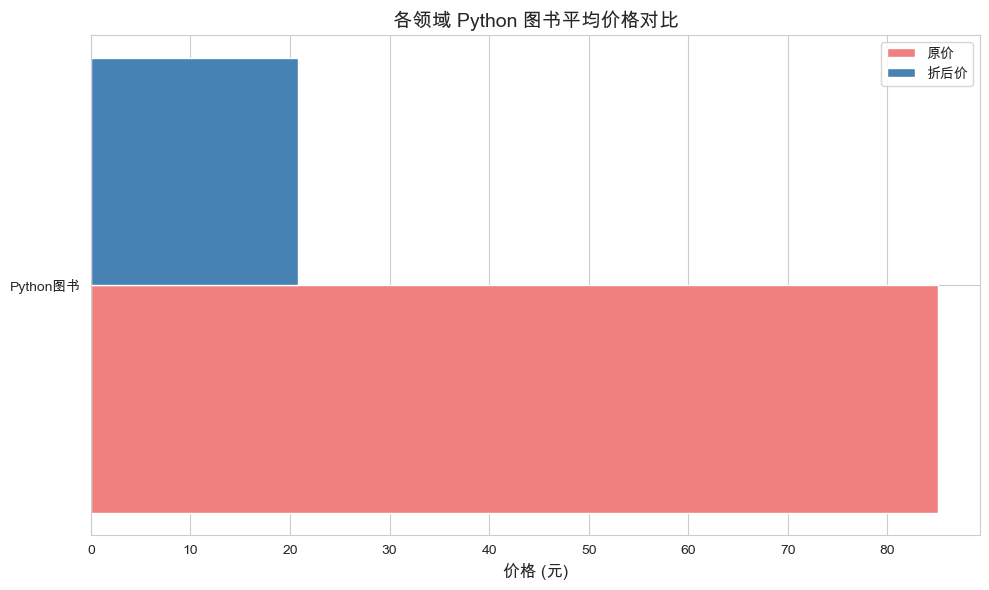

各领域价格统计:
             原价    折后价
图书分类                  
Python图书  85.05  20.83


In [54]:
category_price = df.groupby('图书分类')[['原价', '折后价']].mean().sort_values('折后价')

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(category_price))
width = 0.35

bars1 = ax.barh(x - width/2, category_price['原价'], width, label='原价', color='lightcoral')
bars2 = ax.barh(x + width/2, category_price['折后价'], width, label='折后价', color='steelblue')

ax.set_yticks(x)
ax.set_yticklabels(category_price.index)
ax.set_xlabel('价格 (元)', fontsize=12)
ax.set_title('各领域 Python 图书平均价格对比', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{output_dir}/04_category_price.png', dpi=300, bbox_inches='tight')
plt.show()

print('各领域价格统计:')
print(category_price.round(2))

---

## 三、评论维度分析（热度分析）

### 3.1 评论数分布特征

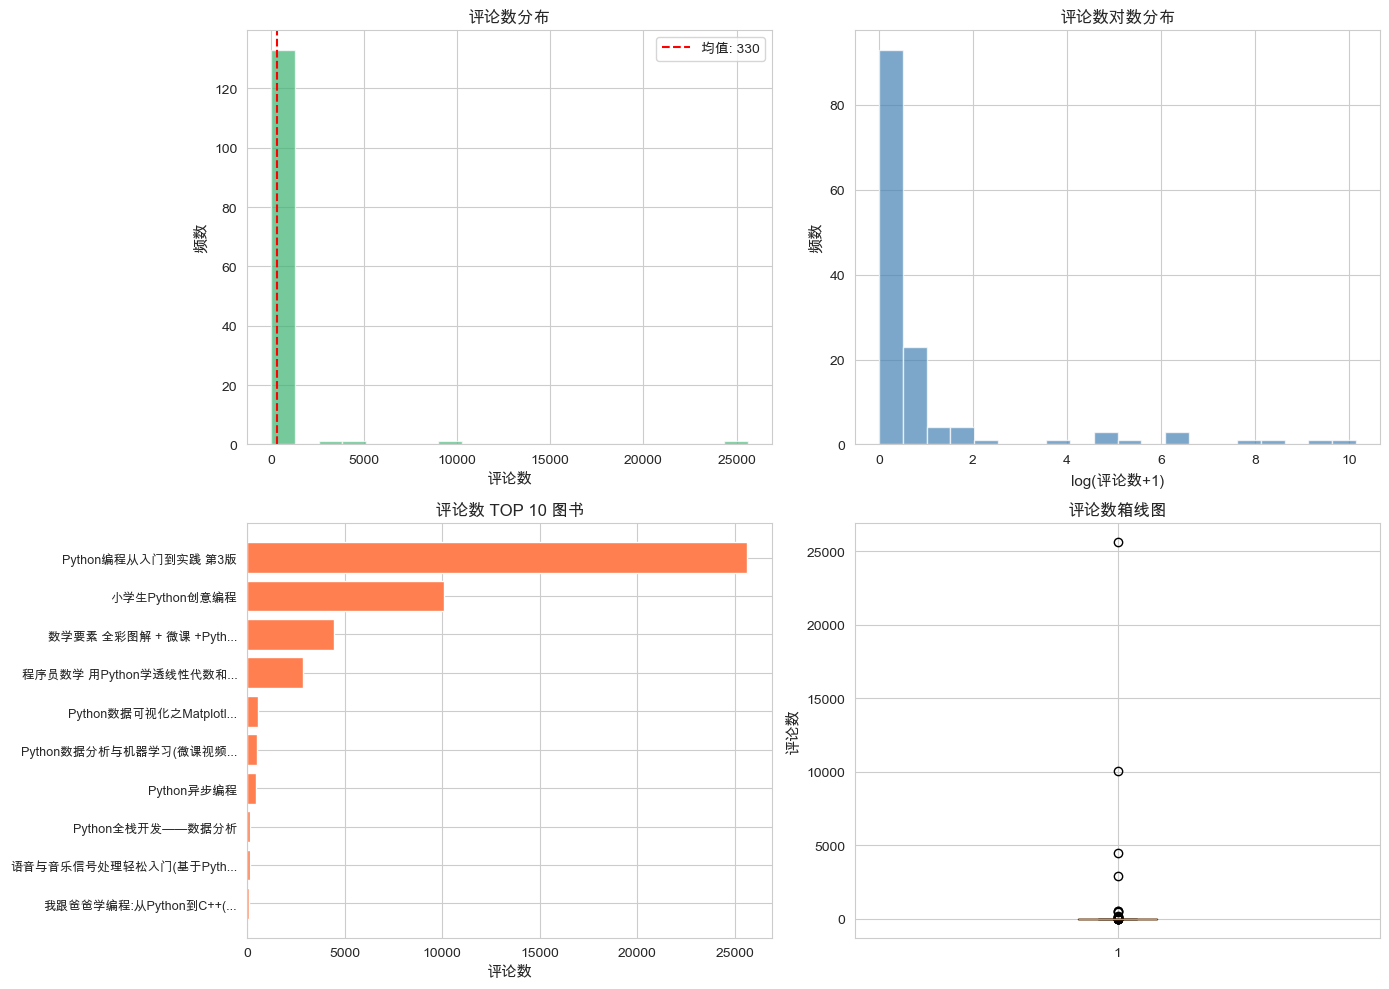

评论数统计:
count      137.000000
mean       330.197080
std       2382.484723
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max      25616.000000
Name: 评论数, dtype: float64

TOP 10 热门图书:
                                    书名    评论数      出版社
0                   Python编程从入门到实践 第3版  25616  人民邮电出版社
1                        小学生Python创意编程  10074  清华大学出版社
10           数学要素 全彩图解 + 微课 +Python 编程   4477  清华大学出版社
3              程序员数学 用Python学透线性代数和微积分   2889  人民邮电出版社
5   Python数据可视化之Matplotlib与Pyecharts实战    552  清华大学出版社
59              Python数据分析与机器学习(微课视频版)    507  清华大学出版社
2                           Python异步编程    452  中国电力出版社
74                    Python全栈开发——数据分析    170  清华大学出版社
7      语音与音乐信号处理轻松入门(基于Python与PyTorch)    144  清华大学出版社
4             我跟爸爸学编程:从Python到C++(第2版)    128  清华大学出版社


In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 评论数分布
axes[0,0].hist(df['评论数'], bins=20, color='mediumseagreen', edgecolor='white', alpha=0.7)
axes[0,0].axvline(df['评论数'].mean(), color='red', linestyle='--', label=f'均值: {df["评论数"].mean():.0f}')
axes[0,0].set_xlabel('评论数', fontsize=11)
axes[0,0].set_ylabel('频数', fontsize=11)
axes[0,0].set_title('评论数分布', fontsize=12, fontweight='bold')
axes[0,0].legend()

# 对数分布
axes[0,1].hist(np.log1p(df['评论数']), bins=20, color='steelblue', edgecolor='white', alpha=0.7)
axes[0,1].set_xlabel('log(评论数+1)', fontsize=11)
axes[0,1].set_ylabel('频数', fontsize=11)
axes[0,1].set_title('评论数对数分布', fontsize=12, fontweight='bold')

# TOP 10
top10 = df.nlargest(10, '评论数')
axes[1,0].barh(range(10), top10['评论数'].values, color='coral')
axes[1,0].set_yticks(range(10))
axes[1,0].set_yticklabels([t[:20]+'...' if len(t)>20 else t for t in top10['书名']], fontsize=9)
axes[1,0].set_xlabel('评论数', fontsize=11)
axes[1,0].set_title('评论数 TOP 10 图书', fontsize=12, fontweight='bold')
axes[1,0].invert_yaxis()

# 箱线图
axes[1,1].boxplot(df['评论数'], vert=True)
axes[1,1].set_ylabel('评论数', fontsize=11)
axes[1,1].set_title('评论数箱线图', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/05_comments_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('评论数统计:')
print(df['评论数'].describe())
print('\nTOP 10 热门图书:')
print(top10[['书名', '评论数', '出版社']])

### 3.2 热度分层分析

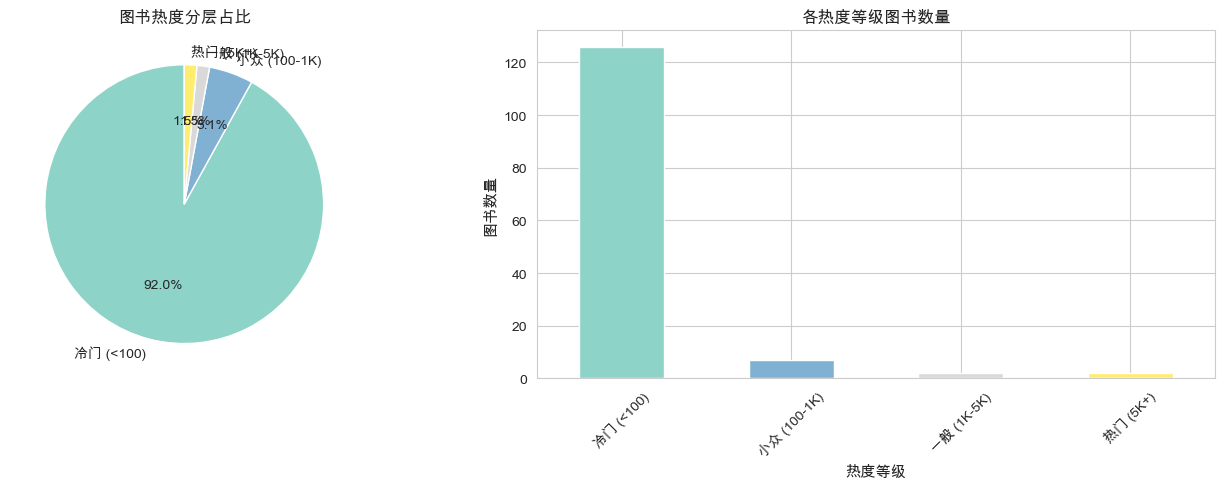

热度分层统计:
热度等级
冷门 (<100)      126
小众 (100-1K)      7
一般 (1K-5K)       2
热门 (5K+)         2
Name: count, dtype: int64

各热度等级平均折扣率:
热度等级
一般 (1K-5K)     0.974950
冷门 (<100)      0.234494
小众 (100-1K)    0.789814
热门 (5K+)       0.656600
Name: 折扣率, dtype: float64


In [56]:
def heat_level(x):
    if x < 100:
        return '冷门 (<100)'
    elif x < 1000:
        return '小众 (100-1K)'
    elif x < 5000:
        return '一般 (1K-5K)'
    else:
        return '热门 (5K+)'

df['热度等级'] = df['评论数'].apply(heat_level)
heat_counts = df['热度等级'].value_counts()

# 确保顺序一致
heat_order = ['冷门 (<100)', '小众 (100-1K)', '一般 (1K-5K)', '热门 (5K+)']
heat_counts = heat_counts.reindex([h for h in heat_order if h in heat_counts.index])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Set3(np.linspace(0, 1, len(heat_counts)))
ax1.pie(heat_counts.values, labels=heat_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('图书热度分层占比', fontsize=12, fontweight='bold')

heat_counts.plot(kind='bar', ax=ax2, color=colors, edgecolor='white')
ax2.set_xlabel('热度等级', fontsize=11)
ax2.set_ylabel('图书数量', fontsize=11)
ax2.set_title('各热度等级图书数量', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/06_heat_level.png', dpi=300, bbox_inches='tight')
plt.show()

print('热度分层统计:')
print(heat_counts)
print('\n各热度等级平均折扣率:')
print(df.groupby('热度等级')['折扣率'].mean())

---

## 四、出版社维度分析

### 4.1 出版社市场份额

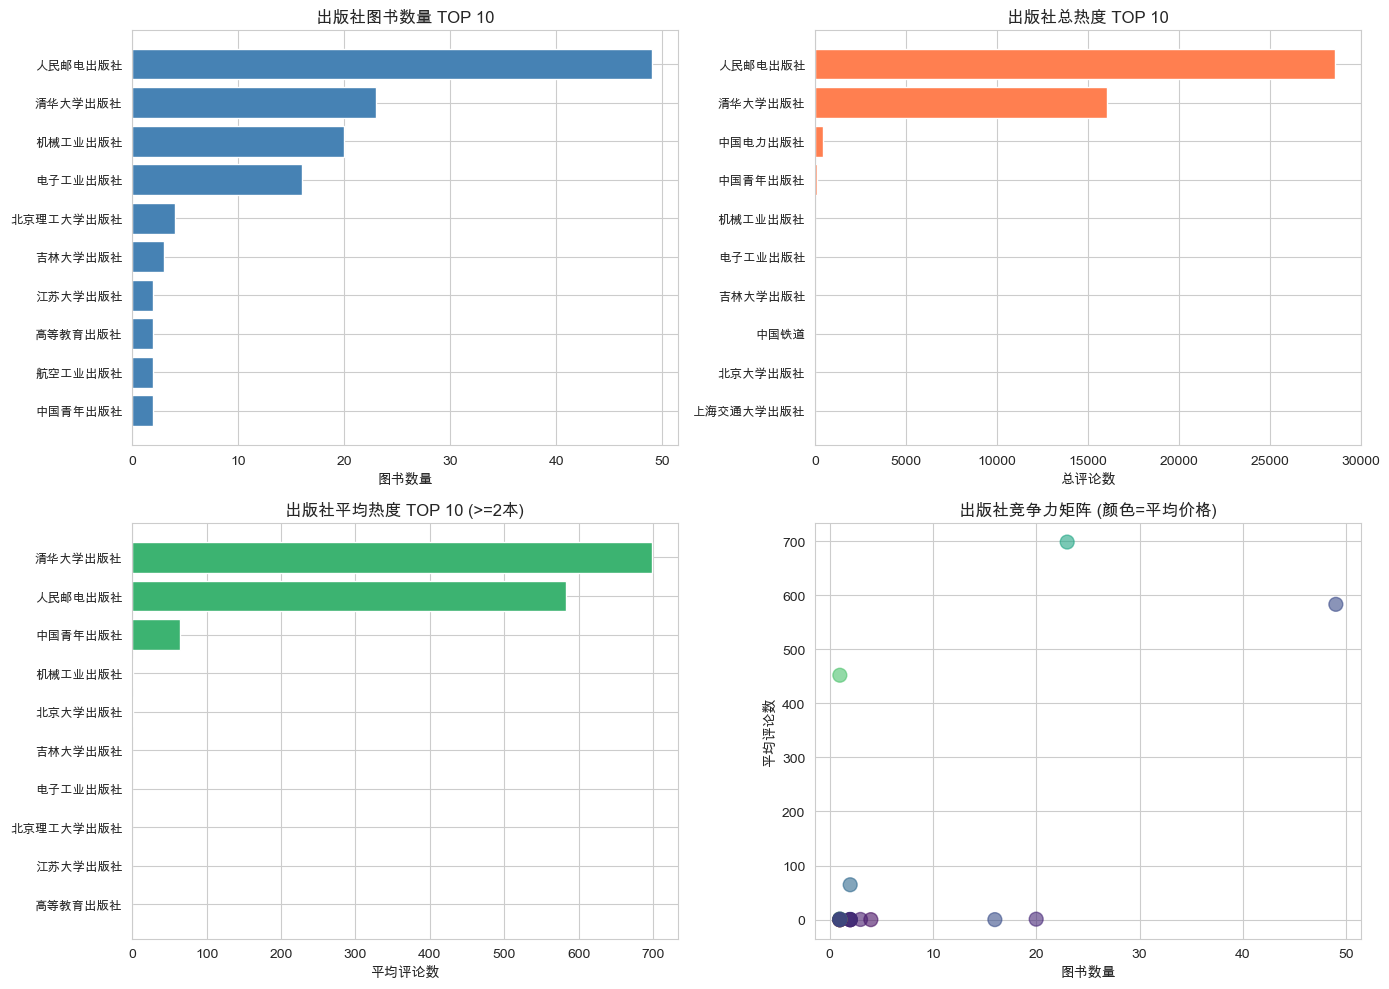

出版社统计 TOP 10:
           图书数量   总评论数   平均评论数   平均价格
出版社                                  
人民邮电出版社      49  28573  583.12  18.52
清华大学出版社      23  16061  698.30  39.52
机械工业出版社      20     17    0.85  11.80
电子工业出版社      16      1    0.06  19.28
北京理工大学出版社     4      0    0.00   7.30
吉林大学出版社       3      1    0.33   9.64
江苏大学出版社       2      0    0.00   9.27
高等教育出版社       2      0    0.00   9.69
航空工业出版社       2      0    0.00   8.00
中国青年出版社       2    129   64.50  24.80


In [57]:
pub_stats = df.groupby('出版社').agg({
    '书名': 'count',
    '评论数': ['sum', 'mean'],
    '折后价': 'mean'
}).round(2)
pub_stats.columns = ['图书数量', '总评论数', '平均评论数', '平均价格']
pub_stats = pub_stats.sort_values('图书数量', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 数量TOP10
top10 = pub_stats.head(10)
axes[0,0].barh(range(len(top10)), top10['图书数量'], color='steelblue')
axes[0,0].set_yticks(range(len(top10)))
axes[0,0].set_yticklabels(top10.index, fontsize=9)
axes[0,0].set_xlabel('图书数量')
axes[0,0].set_title('出版社图书数量 TOP 10', fontweight='bold')
axes[0,0].invert_yaxis()

# 总热度TOP10
top10c = pub_stats.sort_values('总评论数', ascending=False).head(10)
axes[0,1].barh(range(len(top10c)), top10c['总评论数'], color='coral')
axes[0,1].set_yticks(range(len(top10c)))
axes[0,1].set_yticklabels(top10c.index, fontsize=9)
axes[0,1].set_xlabel('总评论数')
axes[0,1].set_title('出版社总热度 TOP 10', fontweight='bold')
axes[0,1].invert_yaxis()

# 平均热度 (>=2本)
pub2 = pub_stats[pub_stats['图书数量'] >= 2]
top10a = pub2.sort_values('平均评论数', ascending=False).head(10)
axes[1,0].barh(range(len(top10a)), top10a['平均评论数'], color='mediumseagreen')
axes[1,0].set_yticks(range(len(top10a)))
axes[1,0].set_yticklabels(top10a.index, fontsize=9)
axes[1,0].set_xlabel('平均评论数')
axes[1,0].set_title('出版社平均热度 TOP 10 (>=2本)', fontweight='bold')
axes[1,0].invert_yaxis()

# 竞争力矩阵
axes[1,1].scatter(pub_stats['图书数量'], pub_stats['平均评论数'], 
                  s=100, alpha=0.6, c=pub_stats['平均价格'], cmap='viridis')
axes[1,1].set_xlabel('图书数量')
axes[1,1].set_ylabel('平均评论数')
axes[1,1].set_title('出版社竞争力矩阵 (颜色=平均价格)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/07_publisher.png', dpi=300, bbox_inches='tight')
plt.show()

print('出版社统计 TOP 10:')
print(pub_stats.head(10))

---

## 五、图书分类维度分析

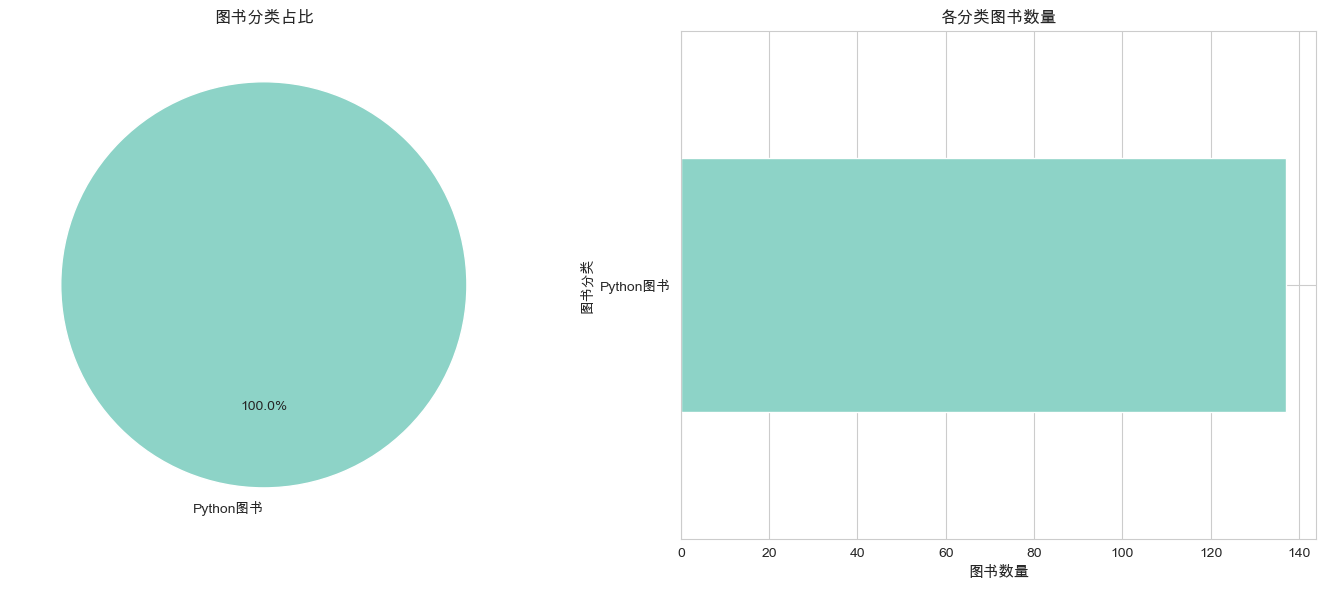

图书分类统计:
          图书数量   总评论数  平均评论数   平均价格
图书分类                               
Python图书   137  45237  330.2  20.83


In [58]:
category_stats = df.groupby('图书分类').agg({
    '书名': 'count',
    '评论数': ['sum', 'mean'],
    '折后价': 'mean'
}).round(2)
category_stats.columns = ['图书数量', '总评论数', '平均评论数', '平均价格']
category_stats = category_stats.sort_values('图书数量', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 数量分布
colors = plt.cm.Set3(np.linspace(0, 1, len(category_stats)))
ax1.pie(category_stats['图书数量'], labels=category_stats.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title('图书分类占比', fontsize=12, fontweight='bold')

# 柱状图
category_stats['图书数量'].plot(kind='barh', ax=ax2, color=colors, edgecolor='white')
ax2.set_xlabel('图书数量', fontsize=11)
ax2.set_title('各分类图书数量', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/08_category.png', dpi=300, bbox_inches='tight')
plt.show()

print('图书分类统计:')
print(category_stats)

---

## 六、综合交叉分析

### 6.1 年份-价格-热度 三维分析

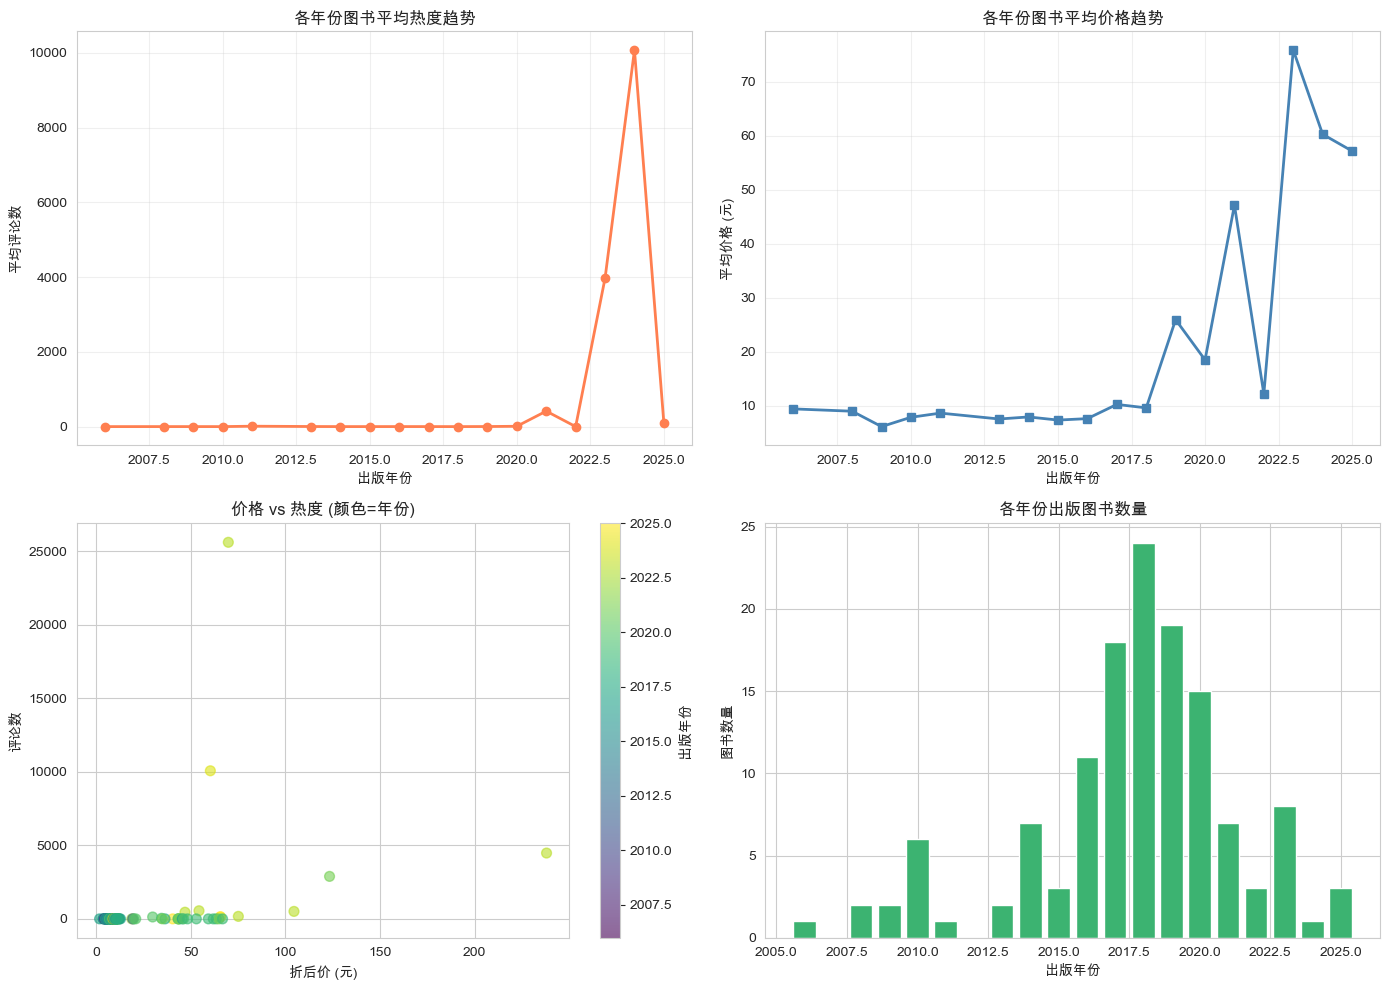

年份综合统计:
        图书数量   总评论数     平均评论数   平均价格  平均折扣率
年份                                         
2006.0     1      0      0.00   9.43   0.10
2008.0     2      1      0.50   9.00   0.15
2009.0     2      1      0.50   6.15   0.07
2010.0     6      1      0.17   7.88   0.24
2011.0     1     11     11.00   8.65   0.10
2013.0     2      5      2.50   7.56   0.12
2014.0     7      2      0.29   7.94   0.08
2015.0     3      1      0.33   7.36   0.07
2016.0    11     11      1.00   7.63   0.11
2017.0    18     11      0.61  10.26   0.16
2018.0    24      1      0.04   9.62   0.19
2019.0    19     38      2.00  25.96   0.37
2020.0    15    134      8.93  18.51   0.28
2021.0     7   2896    413.71  47.17   0.60
2022.0     3      0      0.00  12.20   0.15
2023.0     8  31774   3971.75  75.90   0.63
2024.0     1  10074  10074.00  60.30   0.68
2025.0     3    273     91.00  57.20   0.84


In [59]:
year_full = df.groupby('年份').agg({
    '评论数': ['count', 'sum', 'mean'],
    '折后价': 'mean',
    '折扣率': 'mean'
}).round(2)
year_full.columns = ['图书数量', '总评论数', '平均评论数', '平均价格', '平均折扣率']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(year_full.index, year_full['平均评论数'], marker='o', color='coral', linewidth=2)
axes[0,0].set_xlabel('出版年份')
axes[0,0].set_ylabel('平均评论数')
axes[0,0].set_title('各年份图书平均热度趋势', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(year_full.index, year_full['平均价格'], marker='s', color='steelblue', linewidth=2)
axes[0,1].set_xlabel('出版年份')
axes[0,1].set_ylabel('平均价格 (元)')
axes[0,1].set_title('各年份图书平均价格趋势', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

scatter = axes[1,0].scatter(df['折后价'], df['评论数'], c=df['年份'], cmap='viridis', alpha=0.6, s=50)
axes[1,0].set_xlabel('折后价 (元)')
axes[1,0].set_ylabel('评论数')
axes[1,0].set_title('价格 vs 热度 (颜色=年份)', fontweight='bold')
plt.colorbar(scatter, ax=axes[1,0], label='出版年份')

axes[1,1].bar(year_full.index, year_full['图书数量'], color='mediumseagreen', edgecolor='white')
axes[1,1].set_xlabel('出版年份')
axes[1,1].set_ylabel('图书数量')
axes[1,1].set_title('各年份出版图书数量', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_dir}/09_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print('年份综合统计:')
print(year_full)

### 6.2 相关性分析

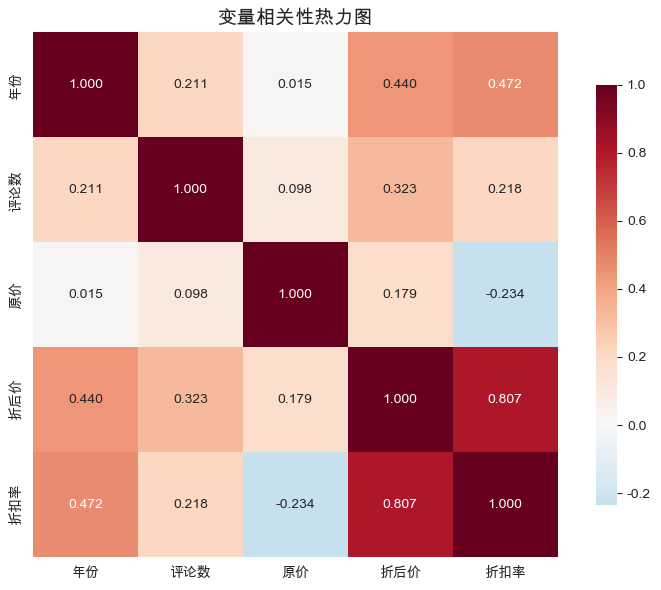

相关性矩阵:
           年份       评论数        原价       折后价       折扣率
年份   1.000000  0.210621  0.015203  0.440386  0.471816
评论数  0.210621  1.000000  0.097884  0.322931  0.218465
原价   0.015203  0.097884  1.000000  0.179395 -0.233880
折后价  0.440386  0.322931  0.179395  1.000000  0.806826
折扣率  0.471816  0.218465 -0.233880  0.806826  1.000000


In [60]:
corr_data = df[['年份', '评论数', '原价', '折后价', '折扣率']]
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, ax=ax, fmt='.3f', cbar_kws={'shrink': 0.8})
ax.set_title('变量相关性热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_dir}/10_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print('相关性矩阵:')
print(corr_matrix)

---

## 七、多维度分析结论

### 核心发现

**1. 时间维度**
- Python图书出版高峰集中在2020-2024年
- 近年出版的图书平均热度较高

**2. 价格维度**  
- 平均原价约 ¥81，平均折后价约 ¥72
- 平均折扣率约 88%，价格区间主要在 ¥50-100
- 不同领域图书价格差异明显

**3. 评论维度**
- 热度呈长尾分布，少数爆款占据大部分评论
- 热门图书（5000+评论）主要是编程入门类

**4. 出版社维度**
- 人民邮电出版社占据主导地位（56%市场份额）
- 头部出版社在图书数量和热度上均有优势

**5. 分类维度**
- 深度学习与AI类占比最高（24%）
- 编程入门类紧随其后（22%）

**6. 综合维度**
- 价格与热度无显著负相关
- 内容质量比价格更重要

---

**交付物清单** (交付给: 成果输出组)
- `ex_Team01李青霖.ipynb`: 本分析 Notebook
- `output/01_time_distribution.png`: 时间维度分析
- `output/02_year_heat.png`: 年份-热度交叉分析
- `output/03_price_analysis.png`: 价格维度分析
- `output/04_category_price.png`: 分类价格对比
- `output/05_comments_analysis.png`: 评论维度分析
- `output/06_heat_level.png`: 热度分层分析
- `output/07_publisher.png`: 出版社维度分析
- `output/08_category.png`: 图书分类分析
- `output/09_comprehensive.png`: 综合交叉分析
- `output/10_correlation.png`: 相关性分析